# 4.0 Modelagem Preditiva e Avaliação

Nesta etapa, desenvolveremos e otimizaremos modelos de Machine Learning para buscar previsões do target `SalePrice`, utilizando: **Scikit-Learn**, **XGBoost** e **LightGBM**.

---
---
# 6.0 Modelagem Preditiva: Modelos Não Lineares (Baseados em Árvores)

Neste segundo caderno, mudamos o paradigma da análise e buscar **algoritmos baseados em árvores de decisão**. Estes modelos se destacam em alta dimensionalidade (como o  `df_treino_tree` com dezenas de colunas do One-Hot Encoding), ignoram a multicolinearidade e buscam relações complexas sem a necessidade de muitas transformações estatísticas ou encondings

---

### **Bagging vs. Boosting**

Uma única Árvore de Decisão (*Decision Tree*) é altamente interpretável, mas sofre com instabilidade e forte tendência ao *overfitting*. Para resolver isso, utilizaremos técnicas de *Ensemble* (combinação de múltiplos modelos):

* **Bagging (Árvores em Paralelo):** Treina diversas árvores **independentes** em amostras aleatórias do dataset e tira a *média* de suas previsões finais. Busca reduzir a **variância** do modelo 
(Ex = RandomForest) 

* **Boosting (Árvores em Série):** Treina árvores de forma **sequencial**, em que cada nova árvore foca em corrigir os erros (resíduos) cometidos por todas as árvores anteriores. É focado em reduzir o viés e atingir performance.
(Ex = XGBoost)




### **Controle do Aprendizado e Validação**

* **Parâmetros vs. Hiperparâmetros:**
  * **Parâmetros:** Regras e nós matemáticos que a árvore `aprende sozinha` ao observar os dados (ex: o ponto exato de corte no tamanho do lote para separar casas caras das baratas).

  * **Hiperparâmetros:** Configurações `anteriormente definidas` para o treino (ex: profundidade máxima das raízes, taxa de aprendizado, número total de árvores). Otimizá-los é o segredo do sucesso do Boosting.

* **K-Fold Cross-Validation:** Para evitar que o modelo seja avaliado por `"sorte"` em uma divisão fácil, os dados de treino serão f`atiados em $K$ pedaços.` O modelo treinará $K$ vezes, rotacionando a fatia de validação, extraindo uma média de erro absoluta e impenetrável ao acaso.

*OBS* = Geralmente usamos K = 5 porque é comum fazer um split com 20% de validação e 80% de treino, de modo que oferece uma estimativa de erro com baixo viés e variância controlada.

*OBS2* K muito grande (Ex = 100) pode fazer a variãncia explodir e tornar o modelo extremamente sensível

### **Estudando os modelos de Árvore (SHAP)**

É comum o estigma de que algoritmos não lineares são inexplicáveis, porém, aplicaremos os valores **SHAP (SHapley Additive exPlanations)**. Essa técnica desconstruirá previsões individuais e globais, nos informando precisamente qual o impacto marginal (em dólares) que cada variável exerceu na precificação final ditada pelo XGBoost ou LightGBM.

__________________________________________________________________________________________

In [9]:
# Importando bibliotecas
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.ticker as ticker
import shap
from shap import TreeExplainer, summary_plot, bar_plot
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV
import time


# Modelos de alta performance
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Configuração de estilo para os gráficos 
sns.set_theme(style="whitegrid")

# Ignorar avisos 
import warnings
warnings.filterwarnings('ignore')

# Definindo o diretório 
caminho = os.getcwd()

# Carregando os datasets
df_treino_tree = pd.read_csv(os.path.join(caminho, "csv_gerados", "df_treino_tree.csv"))
df_teste_tree = pd.read_csv(os.path.join(caminho, "csv_gerados", "df_teste_tree.csv"))
teste_ids = pd.read_csv(os.path.join(caminho, "csv_gerados", "test_ids.csv"))


## *Função para avaliar um modelo com base nas suas métricas*

* `MAE` = Erro absoluto médio

* `RMSE` = Erro médio ao quadrado

* `R²` = Coeficiente de Determinação

O modelo será feito com base em **X_train,  y_train, X_val, y_val, modelo**

#### Protocolo de Avaliação

O treinamento é realizado exclusivamente nos conjuntos de desenvolvimento (**`X_train`** e **`y_train`**). Para diagnosticar problemas de ajuste, a validação segue dois momentos:

1. **Avaliação em Treino:** Mede a aderência do algoritmo aos dados conhecidos para verificar sua capacidade de aprendizado.
2. **Avaliação em Validação:** Testa o modelo em dados não vistos (**`X_val`** e **`y_val`**), simulando o cenário real de predição.

---

#### Métricas Calculadas

* **MAE Treino:** Erro médio absoluto cometido sobre as amostras de treino (US$).
* **MAE Validação:** Erro médio absoluto cometido sobre as amostras de validação (US$).
* **Gap de MAE ($\Delta\text{MAE}$):** Diferença absoluta entre o MAE de validação e o de treino, evidenciando o nível de *overfitting* em dólares.
* **RMSE Treino:** Raiz do erro quadrático médio em treino, monitorando a penalização a erros extremos na base conhecida (US$).
* **RMSE Validação:** Raiz do erro quadrático médio em validação, avaliando a robustez do modelo contra grandes desvios em dados novos (US$).
* **Gap de RMSE ($\Delta\text{RMSE}$):** Diferença entre o RMSE de validação e o de treino, medindo a sensibilidade a *outliers* fora da amostra (US$).
* **$R^2$ Treino:** Coeficiente de determinação na base de treino, indicando a proporção da variância capturada pelo algoritmo.
* **$R^2$ Validação:** Coeficiente de determinação na base de validação, aferindo o poder preditivo real da solução.
* **Gap de $R^2$ ($\Delta R^2$):** Queda de explicação de variância do treino para a validação (adimensional), indicando perda de capacidade de generalização.

In [2]:
def avaliar_modelo(modelo, X_train, y_train, X_val, y_val, nome_modelo):
   
    modelo.fit(X_train, y_train)
    
    # Fazendo previsões na escala log
    pred_train_log = modelo.predict(X_train)
    pred_val_log = modelo.predict(X_val)
    
    # Revertendo o log1p (np.expm1) para calcular o erro real em US$
    y_train_real = np.expm1(y_train)
    y_val_real = np.expm1(y_val)
    pred_train_real = np.expm1(pred_train_log)
    pred_val_real = np.expm1(pred_val_log)
    
    # Calculando métricas na escala original (US$)
    mae_train = mean_absolute_error(y_train_real, pred_train_real)
    mae_val = mean_absolute_error(y_val_real, pred_val_real)
    
    rmse_train = np.sqrt(mean_squared_error(y_train_real, pred_train_real))
    rmse_val = np.sqrt(mean_squared_error(y_val_real, pred_val_real))
    
    r2_train = r2_score(y_train_real, pred_train_real)
    r2_val = r2_score(y_val_real, pred_val_real)
    
    # Exibição estruturada dos resultados
    print(f"==================== {nome_modelo} ====================")
    print(f"MAE Treino:      ${mae_train:,.2f}")
    print(f"MAE Validação:   ${mae_val:,.2f}  (Gap: ${mae_val - mae_train:,.2f})")
    print(f"RMSE Treino:     ${rmse_train:,.2f}")
    print(f"RMSE Validação:  ${rmse_val:,.2f}  (Gap: ${rmse_val - rmse_train:,.2f})")
    print(f"R² Treino:       {r2_train:.4f}")
    print(f"R² Validação:    {r2_val:.4f}  (Gap: {100*(r2_train - r2_val):.4f})%\n")
    
    return modelo

__________________________________________________________________________________________

### **(6.1) Modelos Baseados em Árvores**

Nesta etapa, exploramos algoritmos que lidam com interações complexas entre diversas features, sem a necessidade de pressupostos matemáticos/estatísticos rígidos

Como já dito, eles se diferenciam em `Banging-(Paralelo)` e `Bosting-(Série)`

**Decision Tree**
* **Mecanismo:** Divide o espaço amostral sucessivamente por meio de regras lógicas de decisão (*if-else*), selecionando os pontos de corte nas *features* que mais reduzem a variância do alvo em cada **nó** até alcançar as **folhas** com a previsão final.
* **Vantagens:** Intuitiva, altamente interpretável, dispensa normalização ou padronização de dados e captura relações não lineares complexas sem exigir grandes transformações.
* **Ponto de Atenção:** Apresenta altíssima variância e instabilidade estrutural (pequenas mudanças nos dados alteram a árvore inteira). É extremamente propensa a *overfitting* severo caso critérios de parada (como profundidade máxima e número mínimo de amostras por folha) não sejam rigorosamente configurados.


**Random Forest (Bagging)**
* **Mecanismo:** Constrói centenas de Árvores de Decisão independentes, treinadas em paralelo utilizando amostras aleatórias do *dataset*, e extrai a previsão final através da média de todas elas.
* **Vantagens:** Altamente robusto contra *outliers* e excelente para reduzir a variância geral do modelo.
* **Ponto de Atenção:** Como as árvores são independentes, o modelo não aprende com os próprios erros progressivamente. Pode sofrer *overfitting* se a profundidade das árvores não for limitada.


**Gradient Boosting (Boosting Clássico)**
* **Mecanismo:** Constrói árvores de forma estritamente sequencial. Cada nova árvore é treinada e para tentar prever e corrigir os erros (resíduos) cometidos por todas as árvores anteriores combinadas.
* **Vantagens:** Controle formidável de viés e altíssima precisão preditiva.
* **Ponto de Atenção:** Por não permitir o treinamento em paralelo (uma árvore precisa que a anterior termine), o processo é computacionalmente pesado e lento em grandes volumes de dados.


**XGBoost (Extreme Gradient Boosting)**
* **Mecanismo:** Uma versão moderna e escalável do Gradient Boosting que incorpora penalizações matemáticas nas folhas (Regularização $L_1$ e $L_2$, semelhantes ao Lasso e Ridge) para frear a complexidade.
* **Vantagens:** Extremamente potente, altamente customizável e lida automaticamente com dados nulos e matrizes esparsas.
* **Ponto de Atenção:** Sua agressividade na busca por padrões complexos exige uma otimização de hiperparâmetros (tuning) rigorosa; caso contrário, memoriza os dados de treino e causa *overfitting* severo.


**LightGBM (Light Gradient Boosting Machine)**
* **Mecanismo:** Enquanto o XGBoost cresce as árvores nível por nível (*Level-wise*), o LightGBM cresce as árvores folha a folha (*Leaf-wise*), expandindo sempre o nó que promete a maior redução de erro.
* **Vantagens:** Treinamento incrivelmente rápido e com baixíssimo consumo de memória RAM, otimizado para *datasets* massivos.
* **Ponto de Atenção:** A estratégia de focar apenas nas "piores folhas" tende a gerar árvores muito profundas rapidamente, o que o torna altamente suscetível a *overfitting* em *datasets* pequenos (menos de 10.000 linhas).

In [3]:

# Separando X e y para os modelos de ÁRVORE (Dataset Completo com OHE)
X_tree = df_treino_tree.drop(columns=['SalePrice'])
y_tree = df_treino_tree['SalePrice']

# Divisão em Treino e Validação (80/20)
X_train_tree, X_val_tree, y_train_tree, y_val_tree = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42
)

# Instanciando os modelos base de árvores (sem tunagem ainda)
dec_tree = DecisionTreeRegressor(random_state=42)
rf_reg = RandomForestRegressor(random_state=42)
gb_reg = GradientBoostingRegressor(random_state=42)
xgb_reg = XGBRegressor(random_state=42, objective='reg:squarederror')
# O verbose=-1 no LightGBM silencia avisos chatos no terminal
lgbm_reg = LGBMRegressor(random_state=42, verbose=-1) 

# Avaliando os Modelos Não-Lineares
print("================ AVALIAÇÃO MODELOS DE ÁRVORE ================\n")
avaliar_modelo(dec_tree, X_train_tree, y_train_tree, X_val_tree, y_val_tree, "Decision Tree")
avaliar_modelo(rf_reg, X_train_tree, y_train_tree, X_val_tree, y_val_tree, "Random Forest")
avaliar_modelo(gb_reg, X_train_tree, y_train_tree, X_val_tree, y_val_tree, "Gradient Boosting")
avaliar_modelo(xgb_reg, X_train_tree, y_train_tree, X_val_tree, y_val_tree, "XGBoost")
avaliar_modelo(lgbm_reg, X_train_tree, y_train_tree, X_val_tree, y_val_tree, "LightGBM")

================ AVALIAÇÃO MODELOS DE ÁRVORE ================

==================== Decision Tree ====================
MAE Treino:      $6.43
MAE Validação:   $23,236.91  (Gap: $23,230.48)
RMSE Treino:     $155.32
RMSE Validação:  $33,905.08  (Gap: $33,749.76)
R² Treino:       1.0000
R² Validação:    0.7919  (Gap: 20.8108)%

==================== Random Forest ====================
MAE Treino:      $6,389.56
MAE Validação:   $16,113.65  (Gap: $9,724.09)
RMSE Treino:     $10,515.33
RMSE Validação:  $22,472.75  (Gap: $11,957.42)
R² Treino:       0.9830
R² Validação:    0.9086  (Gap: 7.4452)%

==================== Gradient Boosting ====================
MAE Treino:      $10,240.50
MAE Validação:   $14,346.00  (Gap: $4,105.49)
RMSE Treino:     $14,563.39
RMSE Validação:  $20,342.70  (Gap: $5,779.31)
R² Treino:       0.9674
R² Validação:    0.9251  (Gap: 4.2355)%

==================== XGBoost ====================
MAE Treino:      $939.35
MAE Validação:   $15,716.64  (Gap: $14,777.29)
RMSE Trei

,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


> ### **Desempenho dos Modelos Baseados em Árvores**
>
> | Modelo | MAE Treino | MAE Validação | Gap (MAE) | RMSE Validação | $R^2$ Validação | Gap ($R^2$) |
> | :--- | :---: | :---: | :---: | :---: | :---: | :---: |
> | **Decision Tree** | \$6.43 | \$23,236.91 | \$23,230.48 | \$33,905.08 | 0.7919 | 0.2081 |
> | **Random Forest** | \$6,389.56 | \$16,113.65 | \$9,724.09 | \$22,472.75 | 0.9086 | 0.0745 |
> | **Gradient Boosting** | \$10,240.50 | \$14,346.00 | **\$4,105.49** | \$20,342.70 | 0.9251 | **0.0424** |
> | **XGBoost** | \$939.35 | \$15,716.64 | \$14,777.29 | \$21,347.33 | 0.9175 | 0.0822 |
> | **LightGBM** | \$4,870.34 | \$13,277.15 | \$8,406.81 | \$18,891.14 | **0.9354** | 0.0530 |
>
>
> **Principais Diagnósticos:**
>
> Critérios: Overfitting será considerado um **gap $R^2$ >4%** e o **gap do MAE superior a 30% o MAE de treino**

> 1. **Violação Generalizada (Alto Overfitting):**
> Aplicando os critérios rígidos estabelecidos para o projeto, fica evidente que todos os modelos em suas versões padrão falham. Os gaps superam amplamente esses limites de tolerância. Desse modo, `mostra que os modelos com parâmetros padrão estão hiperajustados (overfitting)`.
>
> 2. **Memorização Extrema de Dados:**
> O fato de a Decision Tree e o XGBoost atingirem erros de treino praticamente nulos (MAE de \$6 e \$939) resulta em punições severas na validação, com **gaps de $R^2$ de 20.8% e 8.2%**, respectivamente. Isso confirma que esses algoritmos **decoraram as peculiaridades do treino**. Isso indica que `sofreram memorização de ruído e falharam em encontrar padrões globais`.
>
> 3. **Melhor Potencial Preditivo e Estabilidade:**
> Apesar da variância elevada, o LightGBM alcançou o menor erro de avaliação global e o melhor $R^2$ de **0.9354** (com gap de 5.3%), enquanto o Gradient Boosting foi o mais estável, encostando no teto de tolerância (gap de MAE de **\$4,105.49** e gap de $R^2$ de apenas **4.24%**). Essa performance bruta evidencia que as árvores capturam relações não-lineares valiosas e que, `com a devida otimização de hiperparâmetros (K-Fold), superarão largamente os modelos lineares`.

### **(6.2) Principais hiperparâmetros**

**Decision Tree (Árvore de Decisão)**
* **max_depth:** Profundidade máxima da árvore. Controla o limite de divisões sucessivas.
* **min_samples_split:** Número mínimo de amostras necessárias em um nó para que ele possa ser dividido.
* **min_samples_leaf:** Número mínimo de amostras exigido em uma folha terminal para evitar ramos hiper-específicos.
* **max_features:** Quantidade de colunas sorteadas para avaliar a melhor divisão em cada nó.

---

**Random Forest**
* **n_estimators:** Número de árvores construídas (Geralmente ideal entre 100 e 500).
* **max_depth:** Limite de crescimento de cada árvore individual na floresta. Essencial para conter o *overfitting* generalizado.
* **min_samples_split e min_samples_leaf:** Mesmo papel da árvore simples, atuando em cada árvore da floresta para suavizar as previsões médias.
* **max_features:** Proporção de variáveis sorteadas por divisão (`'sqrt'`, 0.7, 0.8). Força as árvores a explorarem *features* diferentes, reduzindo a correlação entre elas e diminuindo a variância total.
* **bootstrap:** Se `True`, ativa a amostragem com reposição (*bagging*). Treina cada árvore em um subconjunto de dados levemente diferente criado a partir do dataset original, garantindo a diversidade do modelo e reduzindo o *overfitting*.

---

**Gradient Boosting**
* **n_estimators:** Número de árvores construídas sequencialmente.Nesse caso um número excessivo aqui **pode causar overfitting**, pois as últimas árvores começam a modelar o ruído.
* **learning_rate (Taxa de Aprendizado):** Fator que reduz a contribuição de cada árvore corretora. Taxas menores exigem mais árvores, mas geram modelos que generalizam melhor.
* **max_depth:** Profundidade máxima de cada árvore. Em *boosting*, prefere-se usar árvores rasas (*weak learners*) para evitar a memorização rápida dos dados (Valores usuais: 3 a 5).
* **subsample:** Fração das amostras de treino sorteadas para construir cada árvore. Valores menores que 1.0 introduzem aleatoriedade e reduzem a variância.

---

**XGBoost**
* **n_estimators e learning_rate (eta):** Operam na mesma dinâmica de balanço do Gradient Boosting tradicional.
* **max_depth:** Limite de crescimento estrutural (Valores usuais: 3 a 8).
* **subsample:** Percentual de linhas amostradas por iteração (Valores usuais: 0.6 a 0.9).
* **colsample_bytree:** Percentual de colunas (*features*) sorteadas para cada árvore construída. Útil para evitar que a árvore dependa apenas das *features* dominantes (como `GrLivArea` ou `Luxury_Score`).
* **reg_alpha (L1) e reg_lambda (L2):** Termos de regularização matemática aplicados aos pesos das folhas. Encolhem as previsões extremas e forçam o modelo a ser mais esparso e estável.

---

**LightGBM**
* **num_leaves:** É o hiperparâmetro **mais importante** de controle de complexidade do LightGBM. Como o crescimento da árvore é feito folha a folha (*leaf-wise*), este parâmetro dita a flexibilidade do modelo. Regra de ouro para evitar *overfitting*: garantir que `num_leaves` $< 2^{\text{max\_depth}}$.
* **max_depth:** Limite teto de profundidade. Pode atuar como uma segunda barreira de proteção junto com o `num_leaves`.
* **min_child_samples (min_data_in_leaf):** Quantidade mínima de dados (imóveis) exigida em cada folha terminal. Essencial em datasets pequenos, pois impede que o modelo crie uma folha isolada para "decorar" um único imóvel atípico.
* **subsample e colsample_bytree:** Mecanismos de aleatoriedade de linhas e colunas.

In [4]:
import time
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Configurando o K-Fold para validação cruzada (K=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Dicionário unificado focado em COMBATER OVERFITTING
modelos_e_grids = {
    "Decision Tree": (
        DecisionTreeRegressor(random_state=42),
        {
            'max_depth': [5, 7, 10, 12],
            'min_samples_split': [10, 20, 30],
            'min_samples_leaf': [5, 10, 15, 20],
            'max_features': ['sqrt', 'log2', 0.8]
        }
    ),
    
    "Random Forest": (
        RandomForestRegressor(random_state=42),
        {
            'n_estimators': [200, 300, 500],
            'max_depth': [7, 10, 12, 15],
            'min_samples_split': [10, 15, 20],
            'min_samples_leaf': [4, 7, 10],
            'max_features': [0.6, 0.8, 1.0],
            'bootstrap': [True]
        }
    ),
    
    "Gradient Boosting": (
        GradientBoostingRegressor(random_state=42),
        {
            'n_estimators': [150, 250, 350],
            'learning_rate': [0.01, 0.03, 0.05],
            'max_depth': [4, 5, 6],
            'subsample': [0.7, 0.8, 0.9],
            'min_samples_leaf': [5, 10, 15]
        }
    ),
    
    "XGBoost": (
        # CORREÇÃO AQUI: n_jobs=1 impede o deadlock no XGBoost
        XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=1),
        {
            'n_estimators': [500, 750, 1000],
            'learning_rate': [0.005, 0.01, 0.02],
            'max_depth': [3, 4, 5, 6],
            'subsample': [0.6, 0.7, 0.8],
            'colsample_bytree': [0.5, 0.6, 0.7],
            'min_child_weight': [3, 5, 10],
            'reg_alpha': [0.5, 1.0, 5.0],
            'reg_lambda': [5.0, 10.0, 20.0]
        }
    ),
    
    "LightGBM": (
        # CORREÇÃO AQUI: n_jobs=1 impede o deadlock no LightGBM
        LGBMRegressor(random_state=42, verbose=-1, n_jobs=1),
        {
            'n_estimators': [200, 300, 500],
            'learning_rate': [0.01, 0.03, 0.05],
            'num_leaves': [10, 15, 20],
            'max_depth': [4, 5, 7],
            'min_child_samples': [30, 40, 50],
            'subsample': [0.6, 0.7, 0.8],
            'subsample_freq': [1],
            'colsample_bytree': [0.5, 0.6, 0.7],
            'reg_alpha': [1.0, 5.0, 10.0],
            'reg_lambda': [5.0, 10.0, 20.0]
        }
    )
}

melhores_modelos = {}

print("Iniciando a otimização focada em Regularização (Anti-Overfitting)...\n")

for nome_modelo, (modelo_base, param_grid) in modelos_e_grids.items():
    start_time = time.time()
    print(f"Otimizando: {nome_modelo}...")
    
    search = RandomizedSearchCV(
        estimator=modelo_base,
        param_distributions=param_grid,
        n_iter=30, 
        scoring='neg_mean_absolute_error',
        cv=kf,
        random_state=42,
        n_jobs=-1 # O RandomizedSearchCV gerencia o paralelismo com segurança agora
    )
    
    search.fit(X_train_tree, y_train_tree)
    tempo_gasto = time.time() - start_time
    
    melhor_modelo = search.best_estimator_
    melhores_modelos[nome_modelo] = melhor_modelo
    
    print(f"[{nome_modelo}] otimizado em {tempo_gasto:.1f} segundos.")
    print(f"Melhores parâmetros: {search.best_params_}")
    
    print("=" * 80 + "\n")

Iniciando a otimização focada em Regularização (Anti-Overfitting)...

Otimizando: Decision Tree...
[Decision Tree] otimizado em 4.2 segundos.
Melhores parâmetros: {'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 0.8, 'max_depth': 5}

Otimizando: Random Forest...
[Random Forest] otimizado em 33.1 segundos.
Melhores parâmetros: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.6, 'max_depth': 12, 'bootstrap': True}

Otimizando: Gradient Boosting...
[Gradient Boosting] otimizado em 24.8 segundos.
Melhores parâmetros: {'subsample': 0.7, 'n_estimators': 250, 'min_samples_leaf': 10, 'max_depth': 4, 'learning_rate': 0.03}

Otimizando: XGBoost...
[XGBoost] otimizado em 23.1 segundos.
Melhores parâmetros: {'subsample': 0.8, 'reg_lambda': 5.0, 'reg_alpha': 0.5, 'n_estimators': 750, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.02, 'colsample_bytree': 0.6}

Otimizando: LightGBM...
[LightGBM] otimizado em 2.9 segundos.
Melhores pa

In [10]:
modelos_otimizados = [
    (melhores_modelos["Decision Tree"],     X_train_tree, y_train_tree, X_val_tree, y_val_tree, "Decision Tree (Otimizado)"),
    (melhores_modelos["Random Forest"],     X_train_tree, y_train_tree, X_val_tree, y_val_tree, "Random Forest (Otimizado)"),
    (melhores_modelos["Gradient Boosting"], X_train_tree, y_train_tree, X_val_tree, y_val_tree, "Gradient Boosting (Otimizado)"),
    (melhores_modelos["XGBoost"],           X_train_tree, y_train_tree, X_val_tree, y_val_tree, "XGBoost (Otimizado)"),
    (melhores_modelos["LightGBM"],          X_train_tree, y_train_tree, X_val_tree, y_val_tree, "LightGBM (Otimizado)")
]

# Gerando a tabela de diagnóstico dos modelos otimizados
for x in modelos_otimizados:
    avaliar_modelo(*x)

==================== Decision Tree (Otimizado) ====================
MAE Treino:      $18,858.03
MAE Validação:   $20,849.99  (Gap: $1,991.96)
RMSE Treino:     $27,669.12
RMSE Validação:  $28,790.73  (Gap: $1,121.60)
R² Treino:       0.8825
R² Validação:    0.8499  (Gap: 3.2521)%

==================== Random Forest (Otimizado) ====================
MAE Treino:      $10,340.09
MAE Validação:   $15,812.01  (Gap: $5,471.91)
RMSE Treino:     $17,739.40
RMSE Validação:  $21,971.15  (Gap: $4,231.76)
R² Treino:       0.9517
R² Validação:    0.9126  (Gap: 3.9078)%

==================== Gradient Boosting (Otimizado) ====================
MAE Treino:      $9,590.53
MAE Validação:   $13,645.93  (Gap: $4,055.40)
RMSE Treino:     $14,358.76
RMSE Validação:  $18,621.69  (Gap: $4,262.93)
R² Treino:       0.9683
R² Validação:    0.9372  (Gap: 3.1123)%

==================== XGBoost (Otimizado) ====================
MAE Treino:      $10,841.88
MAE Validação:   $13,645.57  (Gap: $2,803.69)
RMSE Treino:     $

> ### **Desempenho dos Modelos Otimizados**
>
> | Modelo | MAE Treino | MAE Validação | Gap (MAE) | RMSE Validação | $R^2$ Validação | Gap ($R^2$) |
> | :--- | :---: | :---: | :---: | :---: | :---: | :---: |
> | **Decision Tree** | \$18,858.03 | \$20,849.99 | **\$1,991.96** | \$28,790.73 | 0.8499 | 0.0325 |
> | **Random Forest** | \$10,340.09 | \$15,812.01 | \$5,471.91 | \$21,971.15 | 0.9126 | 0.0391 |
> | **Gradient Boosting** | \$9,590.53 | \$13,645.93 | \$4,055.40 | **\$18,621.69** | **0.9372** | 0.0311 |
> | **XGBoost** | \$10,841.88 | **\$13,645.57** | \$2,803.69 | \$19,019.11 | 0.9345 | **0.0181** |
> | **LightGBM** | \$9,962.30 | \$13,880.91 | \$3,918.61 | \$19,682.93 | 0.9299 | 0.0242 |
>
>
> **Principais Diagnósticos:**
>
> Critérios: Overfitting será considerado um **gap $R^2$ >4%** e o **gap do MAE superior a 30% o MAE de treino**
>
> 1. **Boa regularização:**
> Aplicando os critérios rígidos estabelecidos para o projeto, fica evidente a melhora devido à otimização de hiperparâmetros. A memorização extrema vista nos modelos padrão (onde o MAE de treino chegava a beirar zero) foi eliminada. Todos os modelos sem exceção apresentaram **gaps de $R^2$ inferiores a 4%**. Desse modo, `mostra que os modelos otimizados superaram o hiperajuste e agora conseguem generalizar padrões globais com extrema segurança`.
>
> 2. **Equilíbrio e Estabilidade Extrema (XGBoost):**
> O XGBoost destacou-se como o modelo mais robusto da bateria. Além de entregar o menor Erro Absoluto Médio em dados novos (MAE de \$13,645.57), ele cumpriu integralmente ambos os critérios de corte: obteve um gap de $R^2$ minúsculo de apenas **1.81%** e um aumento do MAE de treino para validação de aproximadamente 25.8% (abaixo do teto de 30%). Isso confirma que `o algoritmo atingiu a melhor relação entre altíssimo poder preditivo e resiliência a dados inéditos`.
>
> 3. **Melhor Potencial Preditivo Global (Boosting):**
> Enquanto o XGBoost se destacou na consistência, o Gradient Boosting alcançou o melhor $R^2$ da avaliação (**0.9372**) e o menor RMSE (**\$18,621.69**), empatando tecnicamente no MAE. O LightGBM, que sofria severamente com a variância, recuperou-se após restrições estruturais, baixando seu gap de $R^2$ para 2.42%. Essa performance refinada evidencia que as arquiteturas de Boosting capturaram a complexidade do case

## **(6.3) Interpretando os Modelos Otimizados via SHAP**

O SHAP (SHapley Additive exPlanations) é uma ferramenta utilizada para **explicar as previsões Não Lineares de um modelo de Machine Learning**, mostrando o `quanto cada variável (feature) contribuiu`, positiva ou negativamente, para o resultado final de uma predição.

Ele se torna um poderoso diagnóstico para entender **como e por que a escolha de determinados hiperparâmetros** afeta o comportamento do modelo.

Vamos utilizar para analisar todos os `5 modelos` ( **Decision Tree/ Random Forest / XGBoost / LightGBM / Gradient Boosting** ) em suas versões **otmimizadas** de modo a entender quais são as features que mais contribuíram para as avaliações dos modelos e **realizar análises comparativas de atributos**

Lembrando que os modelos preveem, originalmente, o **ln(1+x) do Salesprice** já que é usado a transfomração log1p. Deve-se fazer as futuras transformações pra entender.



In [21]:
# =========================================================
# ANÁLISE SHAP — Interpretabilidade dos Modelos Otimizados
# =========================================================
import pandas as pd
import numpy as np
import shap

# Modelos a serem analisados
modelos_shap = ["Decision Tree", "Random Forest", "XGBoost", "Gradient Boosting", "LightGBM"]

# Retreinando os modelos com 100% dos dados para a análise SHAP
for nome in modelos_shap:
    melhores_modelos[nome].fit(X_train_tree, y_train_tree)

# Calculando os valores SHAP para todos os modelos e consolidando
shap_data = {}
importancias_consolidadas = {}

for nome in modelos_shap:
    explainer = shap.TreeExplainer(melhores_modelos[nome])
    shap_data[nome] = explainer.shap_values(X_val_tree)

    # Pegando a média absoluta do SHAP de cada feature (escala Log)
    importancias_consolidadas[nome] = np.abs(shap_data[nome]).mean(axis=0)

# Criando o DataFrame consolidado
df_shap_consolidado = pd.DataFrame(importancias_consolidadas, index=X_val_tree.columns)

# 1. Calculando a média logarítmica entre os 5 modelos
df_shap_consolidado['Média_5_Modelos_Log'] = df_shap_consolidado[modelos_shap].mean(axis=1)

# =========================================================
# Interpretando o SHAP 
# =========================================================

#  Convertendo Log para Percentual de Impacto ( e^(SHAP) - 1 ) * 100

df_shap_consolidado['Impacto_Medio_Percentual (%)'] = (np.exp(df_shap_consolidado['Média_5_Modelos_Log']) - 1) * 100

#  
# Convertendo para Dólares ($) baseado num imóvel padrão
PRECO_MEDIANO_IMOVEL = 163000 #

df_shap_consolidado['Impacto_Estimado (US$)'] = PRECO_MEDIANO_IMOVEL * (df_shap_consolidado['Impacto_Medio_Percentual (%)'] / 100)

# Ordenando pelas features mais importantes e formatando para exibição
df_shap_consolidado = df_shap_consolidado.sort_values('Impacto_Estimado (US$)', ascending=False)

# Criando uma visualização formatada para o Dataframe (arredondando e pondo cifrão)
df_exibicao = df_shap_consolidado[['Média_5_Modelos_Log', 'Impacto_Medio_Percentual (%)', 'Impacto_Estimado (US$)']].copy()
df_exibicao['Média_5_Modelos_Log'] = df_exibicao['Média_5_Modelos_Log'].map('{:.4f}'.format)
df_exibicao['Impacto_Medio_Percentual (%)'] = df_exibicao['Impacto_Medio_Percentual (%)'].map('{:.2f}%'.format)
df_exibicao['Impacto_Estimado (US$)'] = df_exibicao['Impacto_Estimado (US$)'].map('${:,.2f}'.format)

print(f"Base de cálculo assumida para US$ (Mediana): Imóvel de ${PRECO_MEDIANO_IMOVEL:,.2f}\n")
display(df_exibicao.head(15))

Base de cálculo assumida para US$ (Mediana): Imóvel de $163,000.00



,Média_5_Modelos_Log,Impacto_Medio_Percentual (%),Impacto_Estimado (US$)
Luxury_Score,0.1409,15.13%,"$24,667.94"
TotalArea,0.1009,10.61%,"$17,299.49"
OverallQual,0.0286,2.90%,"$4,728.52"
GrLivArea,0.0219,2.22%,"$3,613.72"
TotalBaths,0.0191,1.93%,"$3,146.87"
Idade_Reforma,0.0151,1.53%,"$2,486.86"
LotArea,0.0147,1.48%,"$2,409.60"
Idade_Casa,0.0145,1.46%,"$2,373.60"
OverallCond,0.0131,1.32%,"$2,149.66"
GarageCars,0.0113,1.14%,"$1,850.76"


**Analisando o gráfico de Barra SHAP**

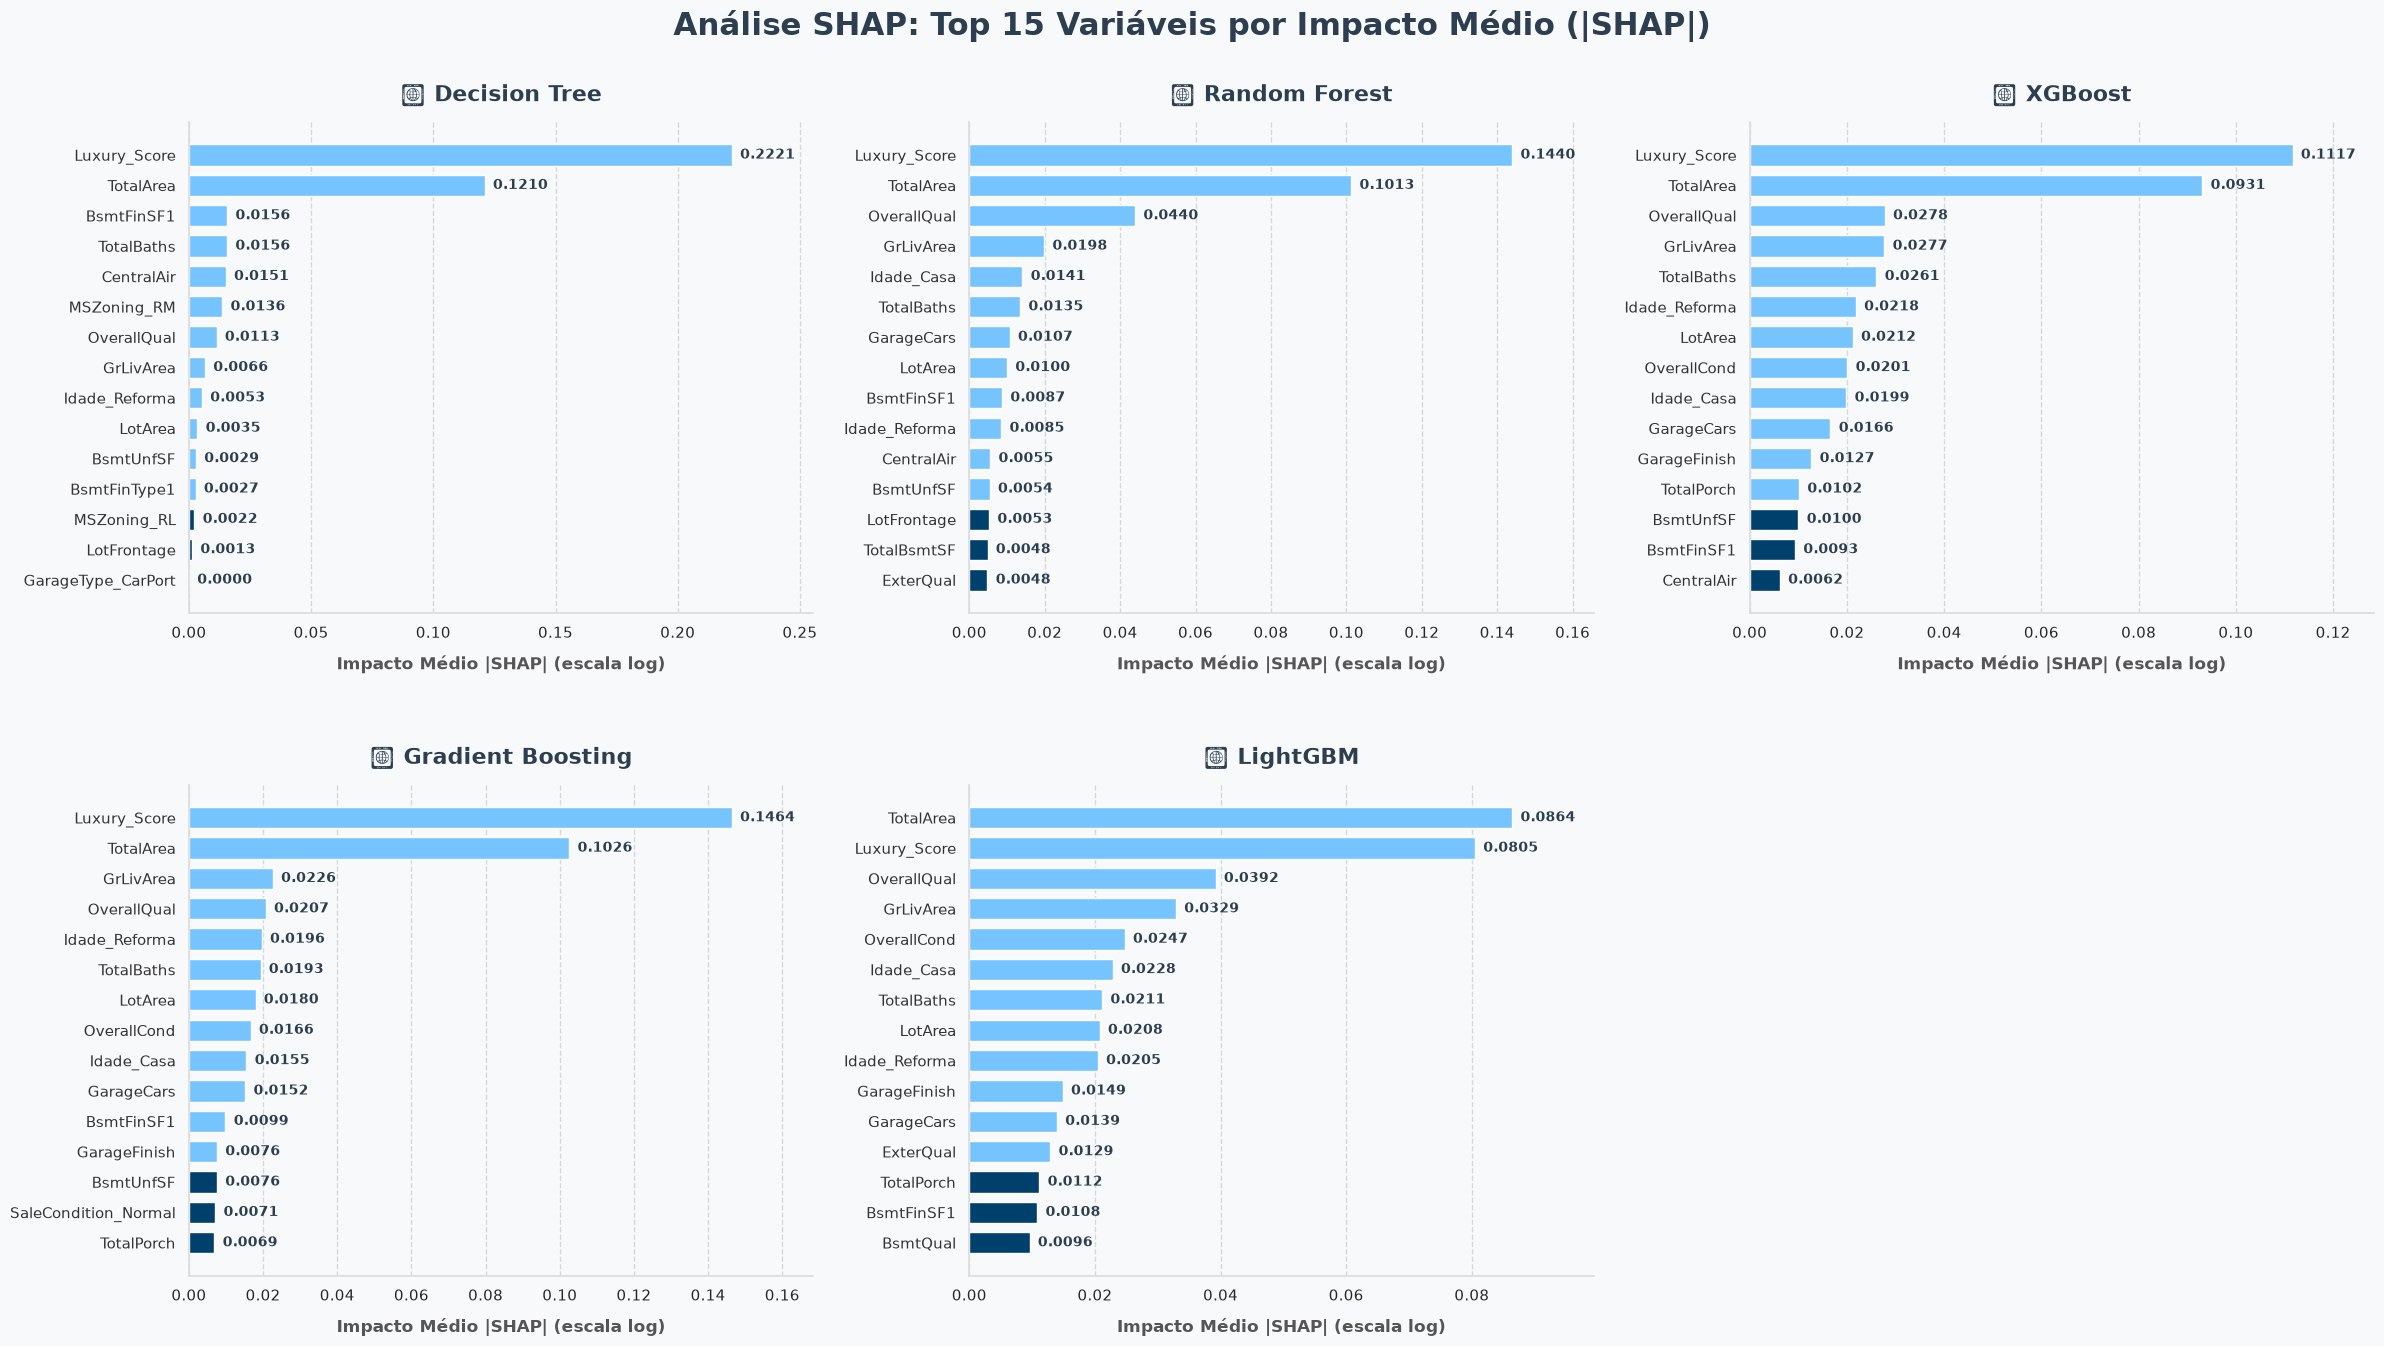

In [ ]:
# Configuração de fundo e paleta de cores moderna
fundo_figura = '#F8F9FA'
cor_texto = '#2C3E50'
cor_destaque = "#00406D" # Azul forte para o Top 3
cor_base = "#75C3FF"     # Azul claro para o restante

fig, axes = plt.subplots(2, 3, figsize=(24, 14), facecolor=fundo_figura)
fig.suptitle('Análise SHAP: Top 15 Variáveis por Impacto Médio (|SHAP|)',
             fontsize=22, fontweight='bold', y=0.96, color=cor_texto)

axes = axes.flatten()

for i, nome in enumerate(modelos_shap):
    ax = axes[i]
    ax.set_facecolor(fundo_figura)
    
    mean_abs_shap = np.abs(shap_data[nome]).mean(axis=0)

    # Criando ranking e selecionando top 15
    ranking_idx = np.argsort(mean_abs_shap)[::-1][:15]
    top_features = [X_val_tree.columns[j] for j in ranking_idx]
    top_values = mean_abs_shap[ranking_idx]

    # Criando regra de cores: As 3 primeiras (mais importantes) escuras, as outras claras
    # Invertemos a ordem no final pois o barh plota de baixo para cima
    cores = [cor_destaque if idx < 3 else cor_base for idx in range(15)][::-1]

    # Plotando as barras mais espessas e elegantes
    y_pos = range(len(top_features)-1, -1, -1)
    bars = ax.barh(y_pos, top_values, color=cores, edgecolor='white', height=0.7)
    
    # 💡 ADIÇÃO PROFISSIONAL: Rótulos de dados no final de cada barra
    ax.bar_label(bars, fmt='%.4f', padding=6, color=cor_texto, fontsize=10, fontweight='bold')

    # Estilizando os eixos
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_features, fontsize=11, fontweight='500', color='#333333')
    
    # Dando espaço (margem de 15%) no final do eixo X para os rótulos não cortarem
    ax.set_xlim(0, max(top_values) * 1.15)
    
    ax.set_xlabel('Impacto Médio |SHAP| (escala log)', fontsize=12, fontweight='bold', color='#555555', labelpad=10)
    ax.set_title(f' {nome}', fontsize=16, fontweight='bold', pad=15, color=cor_texto)
    
    # Limpando a poluição visual (Data-Ink Ratio)
    ax.grid(True, axis='x', linestyle='--', alpha=0.6, color='#BDC3C7')
    ax.grid(False, axis='y') # Sem grid horizontal cruzando as barras
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#DDDDDD')
    ax.spines['bottom'].set_color('#DDDDDD')

# Escondendo o 6º gráfico (índice 5) perfeitamente
axes[5].axis('off')

# Ajustando espaçamento global do dashboard
plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.35, wspace=0.25) 
plt.show()

> ### **Features  mais relevantes para todos os modelos analisados:**
>
> *Analisando a média de impacto financeiro em todos os modelos*
>
> **(1)** `Luxury_Score` (Disparado a mais relevante em todos os modelos ) Impacta 15% em todos os modelos
>
> **(2)** `Total_Area` - 10.61%
>
> **(3)** `OverallQual` - 2.90%
>
> **(4)** `GrLivArea` - 2.22%
>
> **(5)** `Totalbaths` - 1.93%

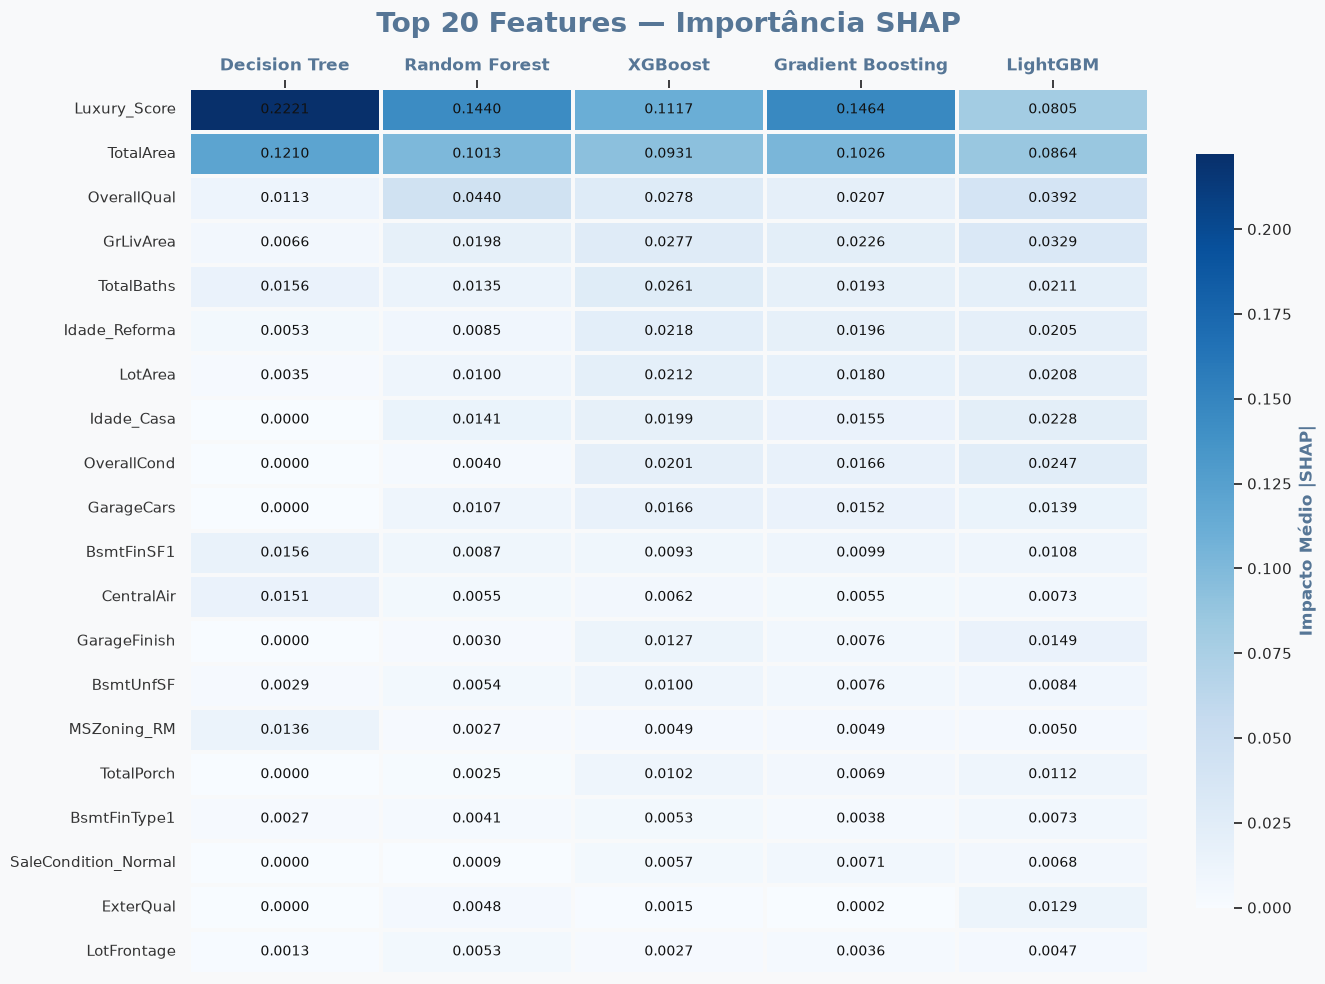

In [32]:
# Configuração de fundo e paleta de cores moderna (harmonia com o gráfico anterior)
fundo_figura = '#F8F9FA'
cor_texto = "#567696"

# 1. ORDENAÇÃO CORRETA PARA HEATMAPS (Maior no topo)
# Ordenamos de forma decrescente e pegamos as 20 primeiras (head)
df_shap_consolidado = df_shap_consolidado.sort_values('Média_5_Modelos_Log', ascending=False)
top_20 = df_shap_consolidado.head(20)

# Criando a figura com o fundo claro
fig, ax = plt.subplots(figsize=(14, 10), facecolor=fundo_figura)
ax.set_facecolor(fundo_figura)

# 2. PLOTANDO O HEATMAP CORPORATIVO
sns.heatmap(
    top_20[modelos_shap],
    annot=True, 
    fmt='.4f', 
    cmap='Blues',               # Gradiente corporativo alinhado ao gráfico de barras
    linewidths=1.5,             # Espaçamento mais largo simulando 'cards' ou 'tiles'
    linecolor=fundo_figura,     # Linhas da mesma cor do fundo para suavizar a grade
    cbar_kws={
        'label': 'Impacto Médio |SHAP|', 
        'shrink': 0.85,         # Encurta levemente a barra de cor para ficar mais elegante
        'pad': 0.04
    },
    annot_kws={'fontsize': 10, 'fontweight': '500', 'color': '#111111'}, 
    ax=ax
)

# 3. ESTILIZAÇÃO PROFISSIONAL DOS EIXOS E TÍTULOS
# Movendo o eixo X (nomes dos modelos) para o topo, como cabeçalho de tabela
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Ajustando fontes dos rótulos (features e modelos)
plt.xticks(fontsize=12, fontweight='bold', color=cor_texto)
plt.yticks(fontsize=11, fontweight='500', color='#333333')

# Removendo labels óbvios que geram poluição visual
ax.set_xlabel('') 
ax.set_ylabel('') 

# Título com espaçamento ajustado para acomodar o eixo X no topo
ax.set_title('Top 20 Features — Importância SHAP',
             fontsize=20, fontweight='bold', color=cor_texto, pad=40)

# 4. ESTILIZANDO A BARRA DE CORES (Colorbar)
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(12)
cbar.ax.yaxis.label.set_weight('bold')
cbar.ax.yaxis.label.set_color(cor_texto)
cbar.outline.set_visible(False) # Remove a borda preta da barra de cor

# Ajuste final
plt.tight_layout()
plt.show()

> ### **Anaĺise do HeatMAP**
>
> Corroborando com o já analisando as features de **Luxury_Score e TotalArea**( Duas features criadas no processo de `feature engineering` são decisivas pra análise dos modelos
>


### **(6.4) Análises Gráficas**

Os gráficos abaixo avaliam a qualidade ds modelos não lineares testados nas validações:

1. **Dispersão (Previsto vs Real)** — O quão próximo da reta perfeita o modelo se encontra
2. **Distribuição dos Resíduos** — Os erros seguem distribuição normal?
3. **QQ Plot** — Confirmação visual da normalidade dos resíduos
4. **Curva de Aprendizado** - Como a quantidade de dados interfere no uso de um determinado modelo?

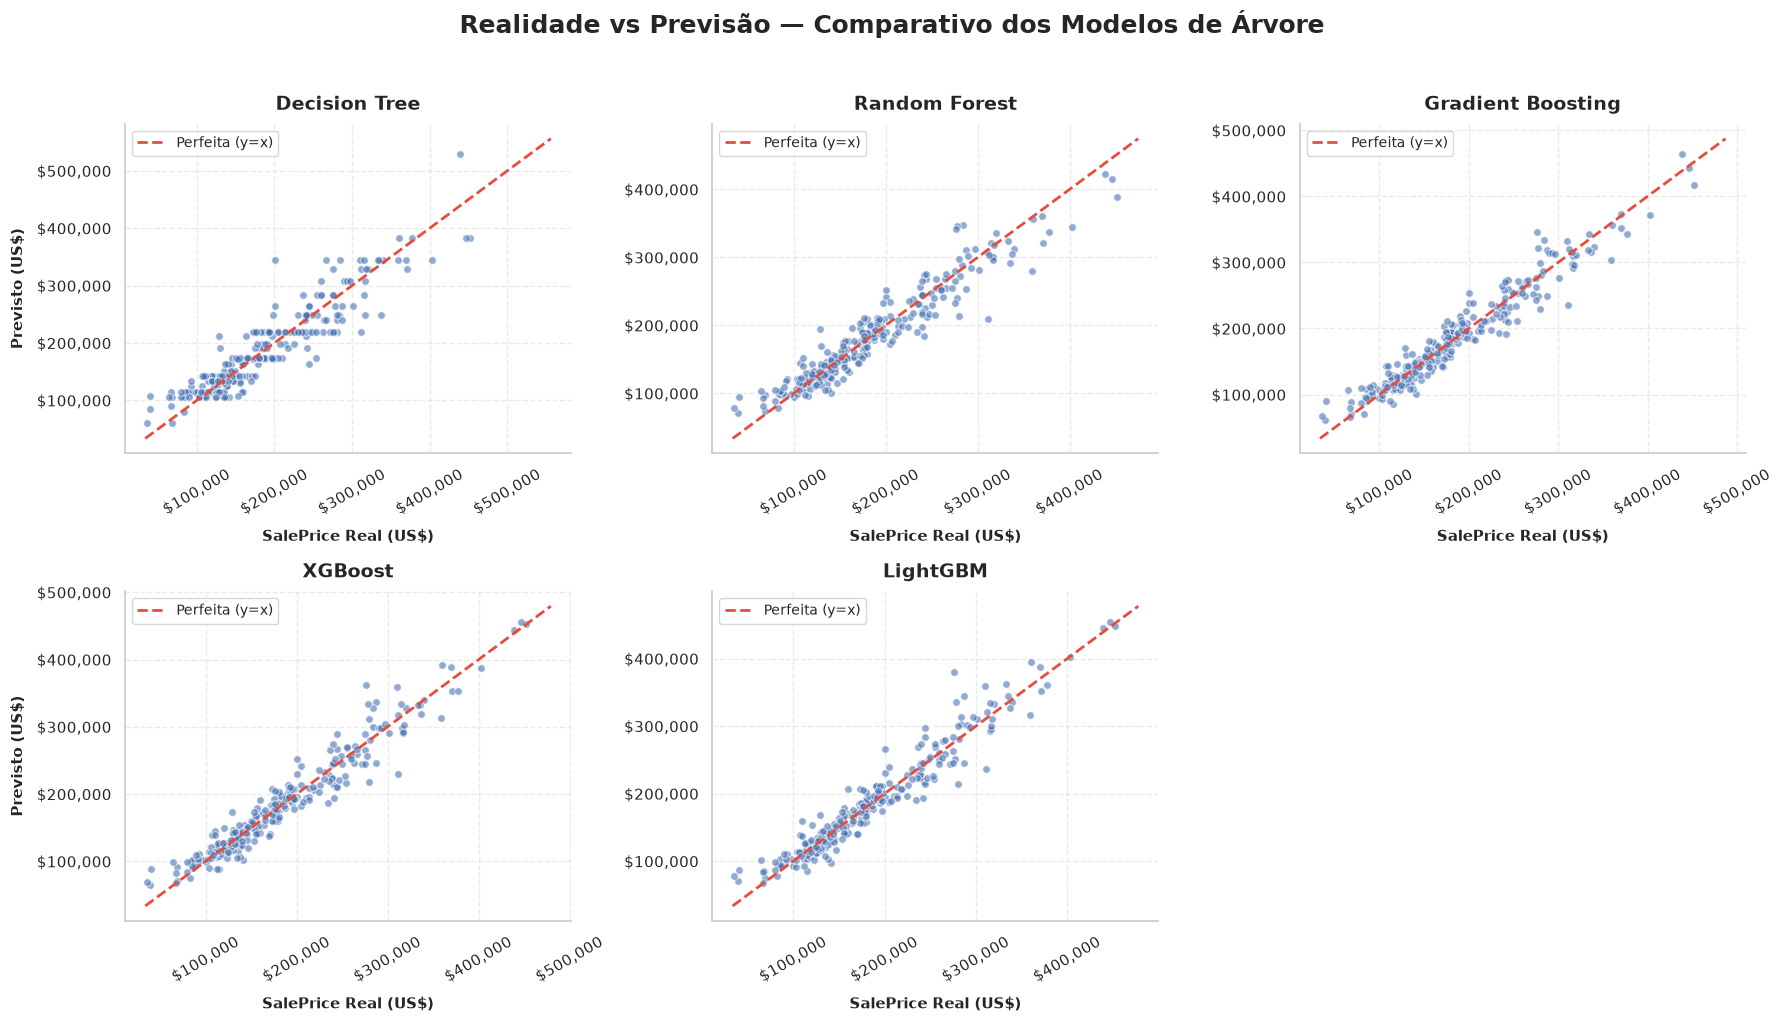

In [ ]:
# =========================================================
# GRÁFICO DE DISPERSÃO: Previsto vs Real 
# =========================================================

# Pré-processamento: Calculando previsões uma única vez
nomes_otim = ["Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost", "LightGBM"]
y_val_r = np.expm1(y_val_tree)
resultados = {}

for nome in nomes_otim:
    modelo = melhores_modelos[nome]
    modelo.fit(X_train_tree, y_train_tree)
    pred_val = np.expm1(modelo.predict(X_val_tree))
    resultados[nome] = {
        'pred': pred_val,
        'residuos': y_val_r - pred_val
    }

# Formatador global de eixos monetários
fmt_moeda = ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')


# Ajustando para 2 linhas e 3 colunas, com um tamanho de figura mais quadrado
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Realidade vs Previsão — Comparativo dos Modelos de Árvore', fontsize=18, fontweight='bold', y=1.02)

# Achata a matriz 2x3 em uma lista linear para facilitar o loop (índices 0 a 5)
axes = axes.flatten()

for i, nome in enumerate(nomes_otim):
    ax = axes[i]
    pred = resultados[nome]['pred']
    
    # Scatter plot com bordas brancas para clareza
    ax.scatter(y_val_r, pred, alpha=0.6, s=30, color="#4672B3", edgecolors='white', linewidth=0.8)
    
    # Reta de identidade (previsão perfeita)
    min_v = min(y_val_r.min(), pred.min()) * 0.95
    max_v = max(y_val_r.max(), pred.max()) * 1.05
    ax.plot([min_v, max_v], [min_v, max_v], '--', color='#E74C3C', linewidth=2, label='Perfeita (y=x)')
    
    # Customização
    ax.set_title(nome, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('SalePrice Real (US$)', fontsize=11, fontweight='bold', labelpad=8)
    
    # Adiciona o label Y apenas no primeiro gráfico de cada linha (índices 0 e 3)
    if i % 3 == 0: 
        ax.set_ylabel('Previsto (US$)', fontsize=11, fontweight='bold', labelpad=8)
    
    ax.xaxis.set_major_formatter(fmt_moeda)
    ax.yaxis.set_major_formatter(fmt_moeda)
    ax.tick_params(axis='x', rotation=30)
    
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper left', frameon=True, fontsize=10)

# Remove o 6º gráfico (índice 5) que sobrou na grade 2x3
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

> ### **Análise Visual: Realidade vs Previsão (Modelos Otimizados)**
>
>
> **Principais Diagnósticos Visuais:**
>
> Critério Visual: Um modelo com 100% de precisão teria todos os pontos sobrepostos exatamente na linha tracejada vermelha ($y=x$). A dispersão vertical dos pontos em relação a essa linha representa o erro residual (distância entre o previsto e o real).
>
> 1. **Limitação Estrutural e Degraus (Decision Tree):**
> O gráfico da **Decision Tree** exibe a maior dispersão geral e um comportamento visual peculiar de "bandas horizontais" (vários pontos alinhados no mesmo eixo Y). Isso acontece porque a árvore cria regras rígidas de decisão, prevendo exatamente o mesmo valor para todos os imóveis que caem em uma mesma folha terminal. Esse padrão visual confirma que `a árvore individual é rígida demais para capturar a variação contínua dos preços no mercado imobiliário`.
>
> 2. **A Supremacia da Arquitetura Boosting (XGBoost e Gradient Boosting):**
> Visualmente, **XGBoost** e **Gradient Boosting** apresentam o agrupamento mais compacto e cilíndrico ao longo da linha tracejada, especialmente na zona de maior densidade de dados (entre \$100.000 e \$300.000). O XGBoost, em particular, mostra uma nuvem extremamente coesa com raros pontos de fuga extremos. Isso corrobora as métricas numéricas anteriores e `comprova de forma gráfica que a regularização aplicada estabilizou os modelos, garantindo previsões seguras e com baixa variância`.
>
> 3. **O Desafio da Cauda Direita (Imóveis de Alto Padrão):**
> Um padrão consistente em todos os cinco gráficos ocorre no quadrante superior direito: à medida que os preços reais ultrapassam a barreira dos **\$350.000**, os pontos começam a descolar e cair abaixo da linha vermelha. Isso significa que todos os modelos estão subestimando (prevendo a menos) os imóveis mais caros. Esse comportamento é típico de algoritmos baseados em árvores e sinaliza que `imóveis de altíssimo padrão fogem do padrão geral e possuem características de valorização atípicas que os dados de treino não conseguem explicar totalmente`.

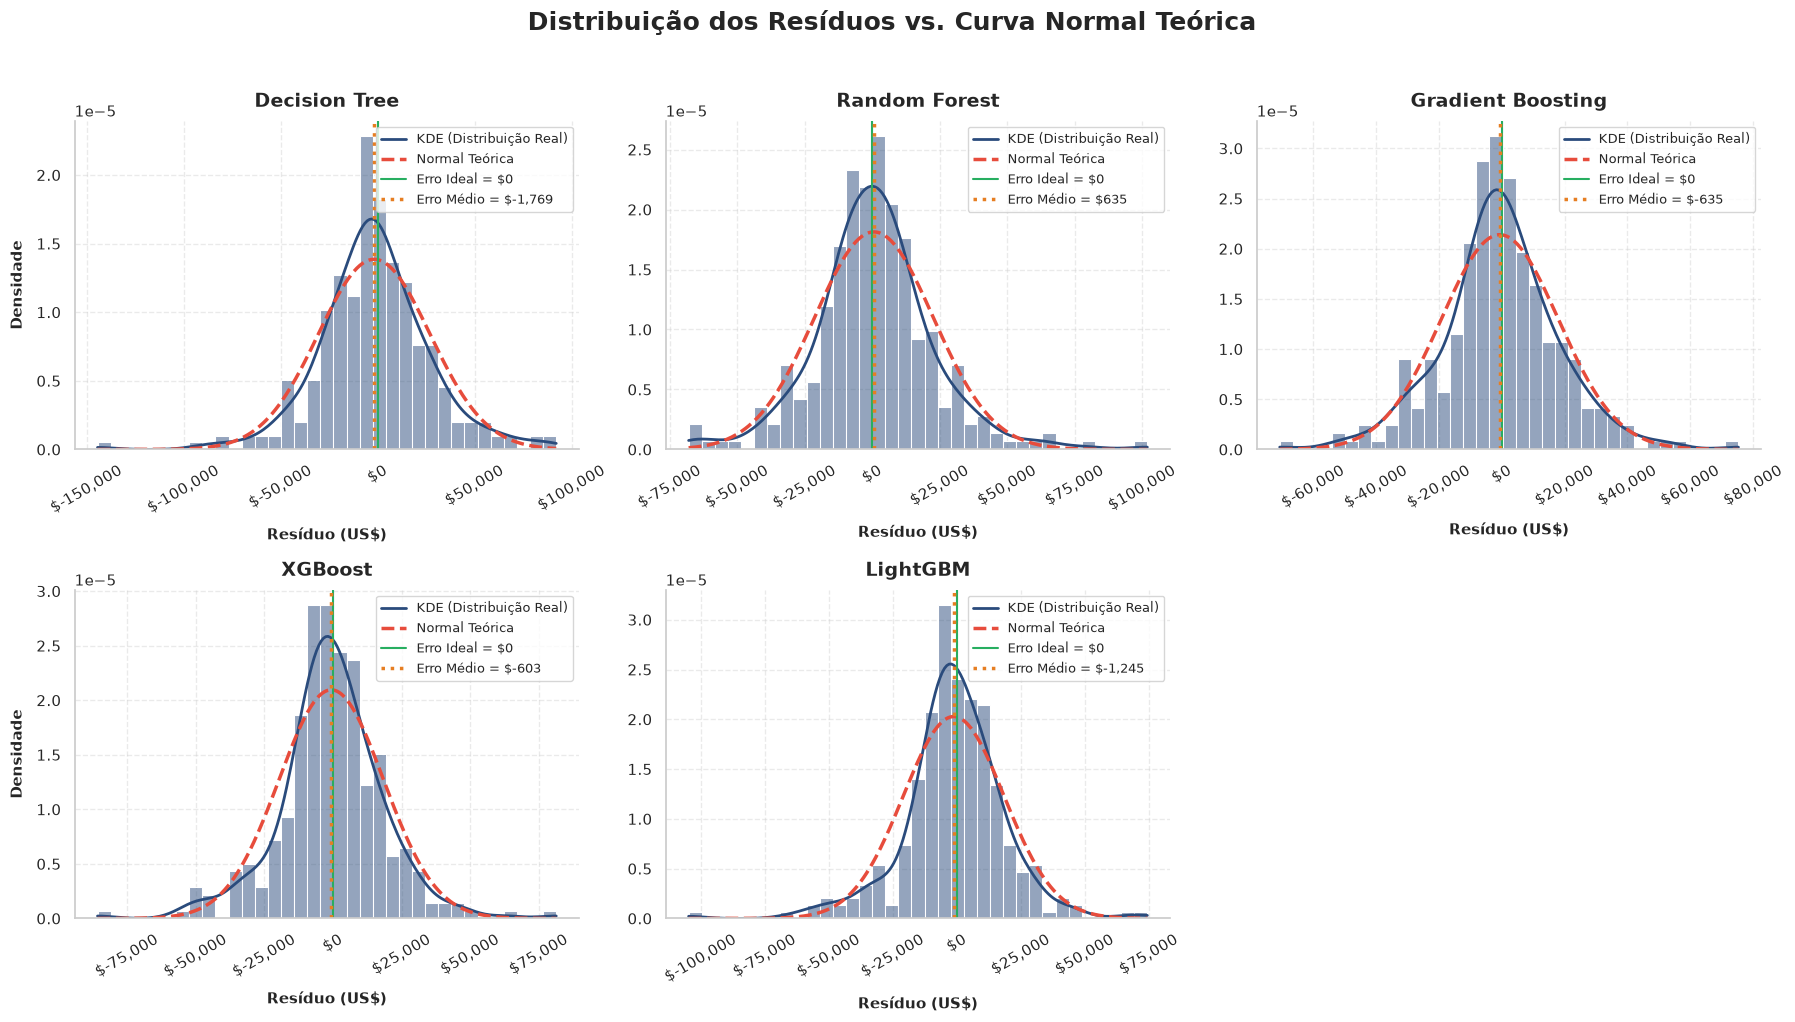

In [ ]:
# =========================================================
# DISTRIBUIÇÃO DOS RESÍDUOS COM CURVA NORMAL TEÓRICA
# =========================================================

# Ajustando para 2 linhas e 3 colunas, com tamanho de figura proporcional
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribuição dos Resíduos vs. Curva Normal Teórica', fontsize=18, fontweight='bold', y=1.02)

# Achata a matriz 2x3 em uma lista linear para facilitar o loop (índices 0 a 5)
axes = axes.flatten()

for i, nome in enumerate(nomes_otim):
    ax = axes[i]
    residuos = resultados[nome]['residuos']
    
    # Histograma suave com KDE (curva de densidade empírica)
    sns.histplot(
        residuos, bins=35, color='#2A4B7C', edgecolor='white', alpha=0.5, 
        stat='density', kde=True, ax=ax, line_kws={'linewidth': 2, 'label': 'KDE (Distribuição Real)'}
    )
    
    # Parâmetros Estatísticos
    media_res = residuos.mean()
    std_res = residuos.std()
    
    # Cria eixo X suave cobrindo toda a amplitude dos resíduos
    x_axis = np.linspace(residuos.min(), residuos.max(), 300)
    # Calcula a densidade da probabilidade normal esperada
    pdf_normal = stats.norm.pdf(x_axis, loc=media_res, scale=std_res)
    
    # Plota a curva vermelha tracejada
    ax.plot(x_axis, pdf_normal, color='#E74C3C', linestyle='--', linewidth=2.5, label='Normal Teórica')
    
    # Linhas de referência (Ideal e Média Real)
    ax.axvline(0, color='#27AE60', linestyle='-', linewidth=1.5, label='Erro Ideal = $0')
    ax.axvline(media_res, color='#E67E22', linestyle=':', linewidth=2.5, label=f'Erro Médio = ${media_res:,.0f}')
    
    # Customização
    ax.set_title(nome, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Resíduo (US$)', fontsize=11, fontweight='bold', labelpad=8)
    
    # Adiciona o label Y apenas no primeiro gráfico de cada linha (índices 0 e 3)
    if i % 3 == 0: 
        ax.set_ylabel('Densidade', fontsize=11, fontweight='bold', labelpad=8)
    else: 
        ax.set_ylabel('')
    
    ax.xaxis.set_major_formatter(fmt_moeda)
    ax.tick_params(axis='x', rotation=30)
    
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper right', frameon=True, fontsize=9)

# Remove o 6º gráfico (índice 5) que sobrou na grade 2x3
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

> ### **Análise Visual: Distribuição dos Resíduos x Curva Normal**
>
>
> **Principais Diagnósticos Visuais:**
>
> Critério Visual: Uma distribuição de resíduos ideal deve ser simétrica, assemelhando-se a um sino perfeitamente centralizado no zero (linha verde). Um pico mais alto e estreito que a Curva Normal Teórica (linha tracejada vermelha) indica alta precisão, pois a esmagadora maioria dos erros está concentrada bem perto de zero.
>
> 1. **Alta Concentração de Acertos:**
> Em todos os cinco gráficos, a linha de densidade real (KDE em azul sólido) forma um pico significativamente mais alto e estreito do que a curva normal teórica (vermelha tracejada). Isso é um resultado excelente. Significa que a distribuição dos erros não é dispersa; pelo contrário, a grande massa das previsões erra por uma margem muito pequena. Isso `comprova visualmente que a etapa de otimização foi bem-sucedida em forçar os modelos a concentrarem suas previsões o mais próximo possível da realidade`.
>
> 2. **Ausência de Viés Sistêmico (Centralidade no Zero):**
> Ao observar as linhas verticais de todos os gráficos, o "Erro Médio" (linha pontilhada laranja) está virtualmente sobreposto ao "Erro Ideal de \$0" (linha sólida verde). Os erros médios absolutos flutuam em valores marginais (como -\$603 no XGBoost ou \$635 no Random Forest). Num contexto de imóveis que custam centenas de milhares de dólares, um desvio médio tão ínfimo `indica que os modelos são globalmente não-viesados, ou seja, eles não sofrem de um vício crônico de sempre superestimar ou subestimar o mercado`.
>
> 3. **Destaque da Arquitetura Boosting (Menor Dispersão):**
> Comparando a extensão do eixo X (base do gráfico), a **Decision Tree** exibe a maior cauda de erros, espalhando-se até a marca de -\$150.000. Por outro lado, os modelos **Gradient Boosting** e **XGBoost** apresentam as bases mais curtas e contidas (limitadas entre -\$60.000 a \$80.000) combinadas com os picos mais altos de densidade (ultrapassando a marca de $3.0 \times 10^{-5}$). Essa compacidade extrema `valida a supremacia do Boosting na eliminação de erros severos, convertendo-os nos algoritmos mais confiáveis e maduros para implementação em produção`.

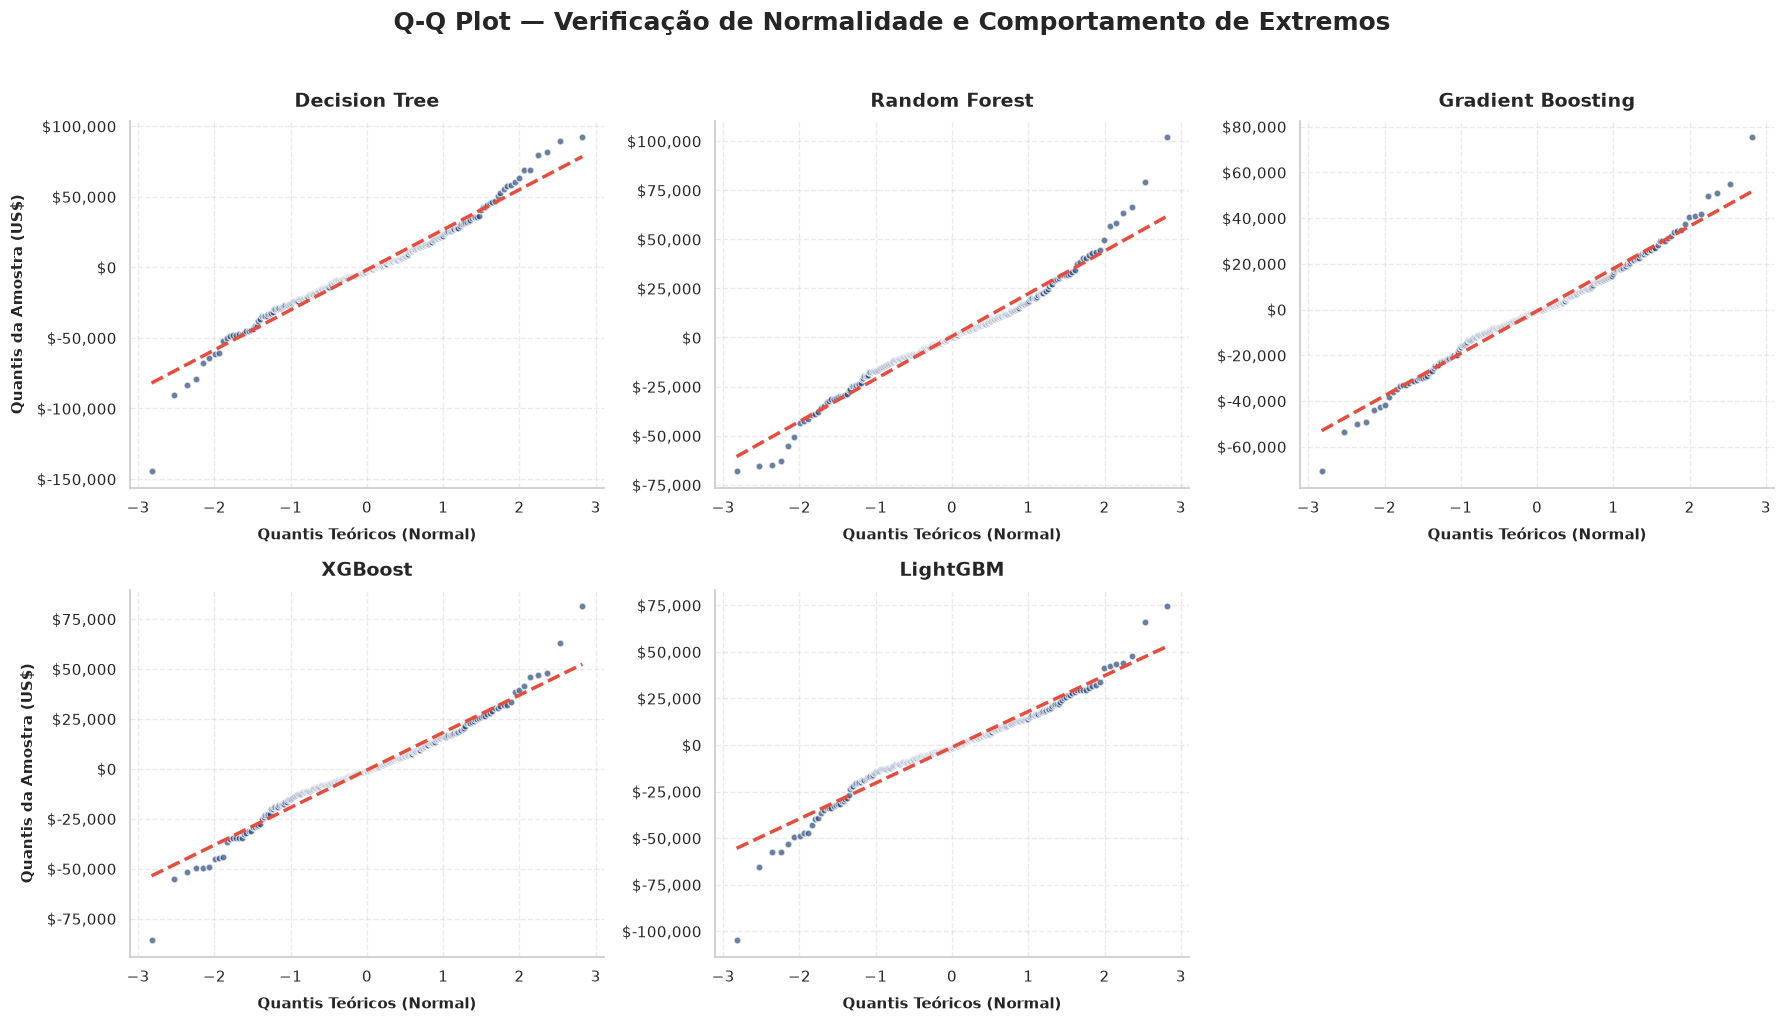

In [ ]:
## =========================================================
# QQ PLOT 
# =========================================================

# Ajustando para 2 linhas e 3 colunas, com tamanho de figura proporcional
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Q-Q Plot — Verificação de Normalidade e Comportamento de Extremos', fontsize=18, fontweight='bold', y=1.02)

# Achata a matriz 2x3 em uma lista linear para facilitar o loop (índices 0 a 5)
axes = axes.flatten()

for i, nome in enumerate(nomes_otim):
    ax = axes[i]
    residuos = resultados[nome]['residuos']
    
    # Geração do Q-Q Plot base
    stats.probplot(residuos, dist="norm", plot=ax)
    
    # Estilização forçada sobre a saída do probplot
    linhas = ax.get_lines()
    linhas[0].set(marker='o', markersize=5, color='#2A4B7C', markeredgecolor='white', alpha=0.7) # Pontos da amostra
    linhas[1].set(color='#E74C3C', linewidth=2.5, linestyle='--') # Linha teórica
    
    # Customização
    ax.set_title(nome, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Quantis Teóricos (Normal)', fontsize=11, fontweight='bold', labelpad=8)
    
    # Adiciona o label Y apenas no primeiro gráfico de cada linha (índices 0 e 3)
    if i % 3 == 0: 
        ax.set_ylabel('Quantis da Amostra (US$)', fontsize=11, fontweight='bold', labelpad=8)
    else: 
        ax.set_ylabel('')
    
    # O eixo Y do Q-Q Plot representa o valor do resíduo, então aplicamos o formatador financeiro
    ax.yaxis.set_major_formatter(fmt_moeda)
    
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Ajustando título automático gerado pelo probplot que pode sobrepor o nosso
    ax.set_title(nome, fontsize=14, fontweight='bold', pad=10)

# Remove o 6º gráfico (índice 5) que sobrou na grade 2x3
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

> ### **Análise Visual: Q-Q Plot — Verificação de Normalidade e Comportamento de Extremos**
>
>
> **Principais Diagnósticos Visuais:**
>
> Critério Visual: Em um Q-Q Plot (Quantil-Quantil), se os resíduos seguem uma distribuição perfeitamente normal, os pontos azuis devem se alinhar de forma exata sobre a linha vermelha pontilhada diagonal. Desvios nas extremidades (caudas superior e inferior) indicam a presença de assimetria ou valores extremos (*outliers*) que escapam do comportamento gaussiano ideal.
>
> 1. **Aderência Central Quase Perfeita:**
> Observando o miolo de todos os gráficos (entre os quantis teóricos -1 e 1), os pontos azuis aderem de muito bem à linha vermelha diagonal. Isso confirma que `o erro residual na imensa maioria das previsões comporta-se de forma estritamente normal, validando as premissas estatísticas dos modelos otimizados`. 
>
> 2. **Comportamento de Caudas Pesadas (Fuga nos Extremos):**
> Em todos os modelos, percebe-se um desvio característico nas pontas extremas (cauda inferior esquerda e cauda superior direita), onde os pontos se distanciam da linha vermelha e sobem ou descem de forma mais acentuada. Esse fenômeno demonstra que `os modelos possuem caudas pesadas, refletindo a dificuldade inerente em prever com exatidão os imóveis de preços muito baixos ou de altíssimo padrão, cujos erros assumem valores maiores que a média`.
>
> 3. **Consistência Estrutural do Boosting (XGBoost e Gradient Boosting):**
> Comparando as escalas do eixo vertical (Quantis da Amostra), a **Decision Tree** e o **Random Forest** estendem-se até \$100.000 de desvio nas pontas. Em contrapartida, os modelos baseados em **XGBoost**, **Gradient Boosting** e **LightGBM** contêm esses desvios extremos de forma mais compacta (geralmente limitados a \$75.000). Essa contenção reforça visualmente que `as arquiteturas de Boosting controlam melhor a volatilidade dos resíduos nos extremos, consolidando-se como as opções mais estáveis para o negócio`.

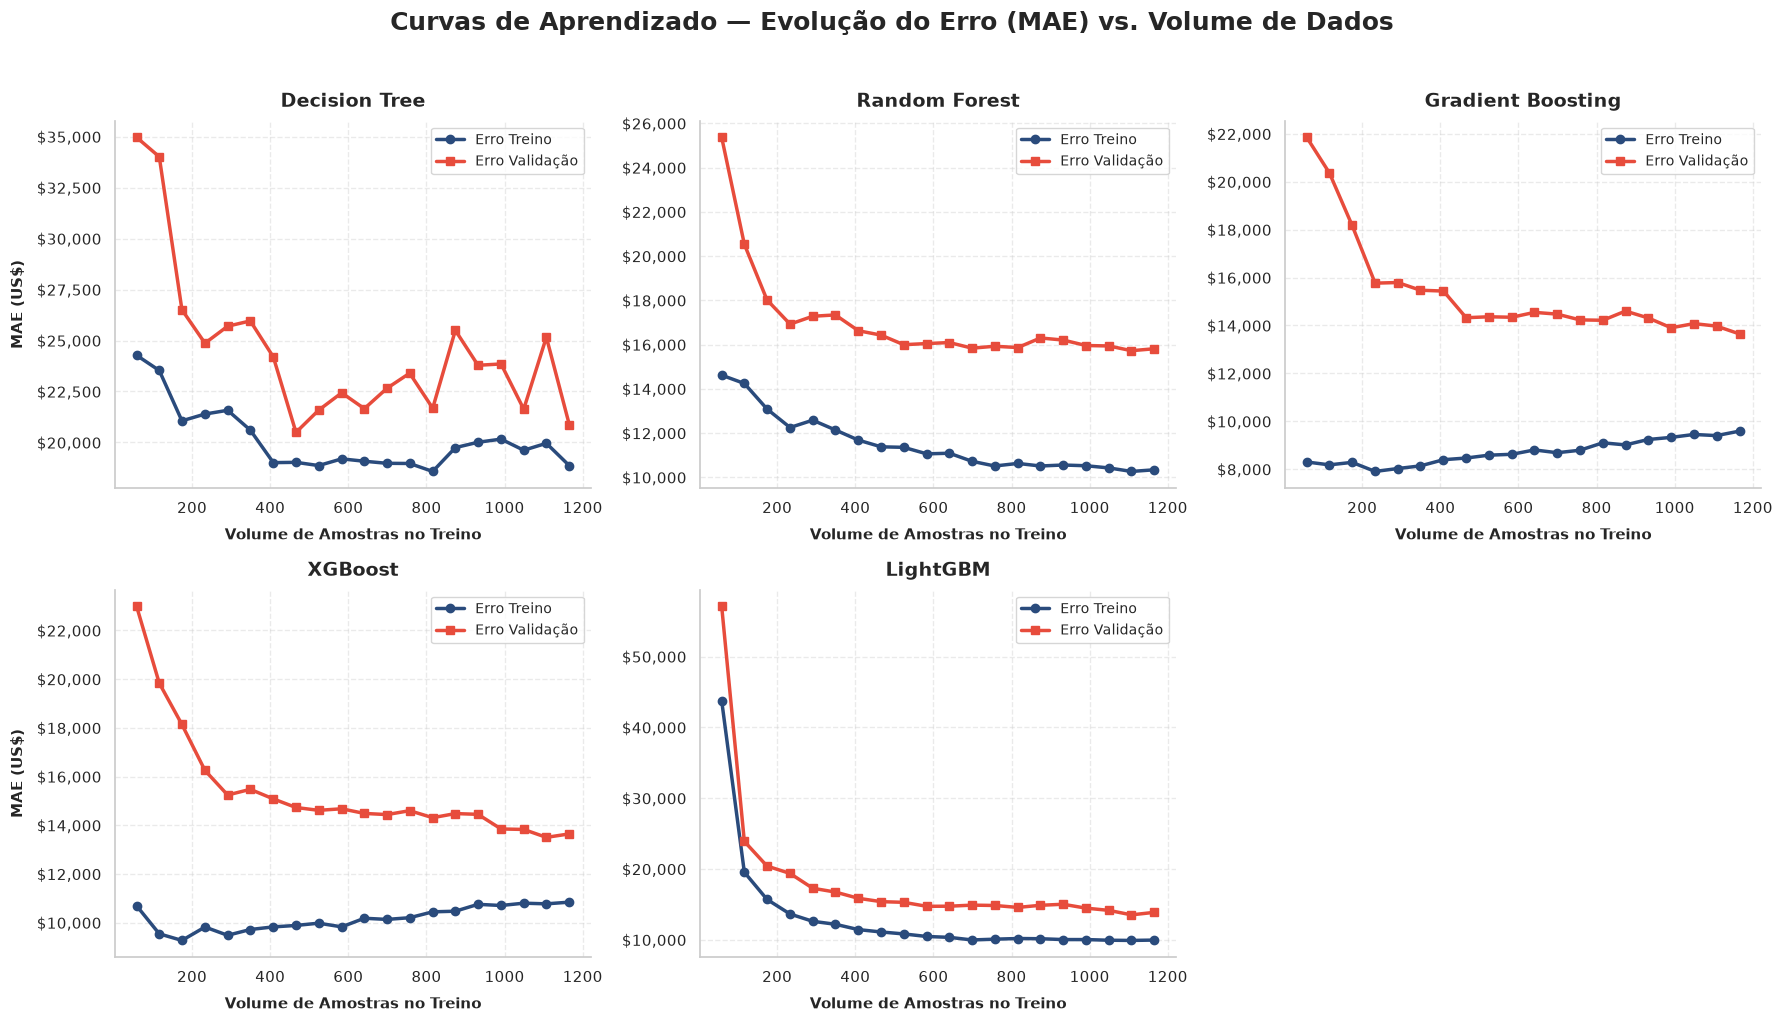

In [ ]:
## =========================================================
# Curvas de aprendizado
# =========================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Curvas de Aprendizado — Evolução do Erro (MAE) vs. Volume de Dados', 
             fontsize=18, fontweight='bold', y=1.02)

axes = axes.flatten()

# Fatias do dataset: testando o modelo com 10%, 30%, 50%, 75% e 100% dos dados
proporcoes = [x for x in np.arange(0.05, 1.05, 0.05)]  # 5%,10%, 15%, ..., 100%
n_amostras = len(X_train_tree)

for i, nome in enumerate(nomes_otim):
    ax = axes[i]
    modelo = melhores_modelos[nome]
    
    train_erros = []
    val_erros = []
    tamanhos_x = []
    
    # Loop de treinamento progressivo
    for prop in proporcoes:
        limite = int(n_amostras * prop)
        # Seleciona apenas uma fatia dos dados
        X_subset = X_train_tree.iloc[:limite]
        y_subset = y_train_tree.iloc[:limite]
        
        # Treina o modelo apenas na fatia
        modelo.fit(X_subset, y_subset)
        
        # Previsões revertendo a escala logarítmica (expm1)
        pred_train = np.expm1(modelo.predict(X_subset))
        pred_val = np.expm1(modelo.predict(X_val_tree))
        
        # Cálculo do MAE em Dólares
        mae_train = mean_absolute_error(np.expm1(y_subset), pred_train)
        mae_val = mean_absolute_error(np.expm1(y_val_tree), pred_val)
        
        train_erros.append(mae_train)
        val_erros.append(mae_val)
        tamanhos_x.append(limite)
        
    # Plotagem das linhas de erro
    ax.plot(tamanhos_x, train_erros, 'o-', color='#2A4B7C', label='Erro Treino', linewidth=2.5, markersize=6)
    ax.plot(tamanhos_x, val_erros, 's-', color='#E74C3C', label='Erro Validação', linewidth=2.5, markersize=6)
    
    # Customização visual
    ax.set_title(nome, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Volume de Amostras no Treino', fontsize=11, fontweight='bold', labelpad=8)
    
    if i % 3 == 0:
        ax.set_ylabel('MAE (US$)', fontsize=11, fontweight='bold', labelpad=8)
    
    ax.yaxis.set_major_formatter(fmt_moeda)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper right', frameon=True, fontsize=10)

# Ocultando o 6º gráfico vazio
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

# Após gerar o gráfico, é necessário retreinar os modelos com 100% dos dados
# para garantir que os objetos no dicionário fiquem prontos para uso futuro
for nome in nomes_otim:
    melhores_modelos[nome].fit(X_train_tree, y_train_tree)

> ### **Análise Visual: Curvas de Aprendizado — Evolução do Erro (MAE) vs. Volume de Dados**

>
> **Principais Diagnósticos Visuais:**
>
> Critério Visual: As curvas de aprendizado exibem a evolução do erro de treino (azul) e de validação (laranja) conforme o volume de amostras aumenta. O comportamento ideal é a convergência gradual entre ambas as curvas (redução do gap), indicando que o modelo absorve conhecimento útil e se estabiliza sem sofrer com escassez ou excesso de dados.
>
> 1. **Convergência e Estabilização (XGBoost e Gradient Boosting):**
> Nos gráficos de **XGBoost** e **Gradient Boosting**, observa-se que a curva de validação cai acentuadamente no início e estabiliza em um patamar sólido e de baixa variabilidade conforme o volume de dados se aproxima de 1.200 amostras. A linha azul de treino mantém-se estável ou com leve inclinação ascendente controlada. Isso `comprova que os modelos de Boosting se beneficiam plenamente do volume de dados e já atingiram uma zona de maturidade preditiva estável`.
>
> 2. **Comportamento Errático na Árvore Isolada (Decision Tree):**
> O gráfico da **Decision Tree** revela uma volatilidade extrema na curva de validação (linha laranja cheia de picos e vales acentuados mesmo em volumes maiores de dados). Isso ocorre porque uma árvore individual é altamente sensível a adições pontuais de amostras no conjunto de treino. Esse comportamento errático `evidencia a fragilidade estrutural da árvore isolada, justificando a necessidade de algoritmos de ensemble para eliminar ruídos de amostragem`.
>
> 3. **Curvas de Aprendizado Saudáveis nos Ensembles (Random Forest e LightGBM):**
> Tanto o **Random Forest** quanto o **LightGBM** demonstram uma separação saudável e constante entre as curvas de treino e validação a partir do meio do eixo X, sem sinais de cruzamento anômalo ou degradação. O LightGBM, em particular, exibe uma queda vertiginosa inicial no erro de validação (partindo de cima de \$50.000) até estacionar na faixa dos \$14.000. Essa estabilização final horizontalizada `confirma que a regularização aplicada impediu o colapso por overfitting, garantindo curvas consistentes e prontas para produção`.

> ### **(6.4) Veredito Final**
>
> * Diante das análises feitas acima, verificou-se que os modelos de Boosting se adaptaram muito melhor para esse case de previsão de valores imobiliários. 
>
> * Nesse sentido, o melhor modelo não linear para a previsão dos valores de imóveis, sem dúvidas, é o modelo de **XGBoosting Otimizado**, consolidando a melhor relação entre precisão absoluta, estabilidade de generalização, GAP MAE e GAP R².

In [ ]:
#======================================================================================================
# Exportando o csv para a competição do Kaggle
#======================================================================================================

# Treinando o XGBoost otimizado com toda a base de treino (X_tree e y_tree já definidos)
print("Treinando o XGBoost otimizado com 100% dos dados de treino...")
modelo_final = melhores_modelos["XGBoost"]
modelo_final.fit(X_tree, y_tree)

# Calculando as previsões na escala log e revertendo com expm1
print("Gerando as previsões para o conjunto de teste...")
previsoes_log = modelo_final.predict(df_teste_tree)
previsoes_finais = np.expm1(previsoes_log)

# Criando o DataFrame no formato exigido pelo Kaggle
submissao = pd.DataFrame({
    'Id': teste_ids['Id'],
    'SalePrice': previsoes_finais
})

# Exportando o arquivo CSV final
caminho_submissao = os.path.join(caminho, "csv_gerados", "submission.csv")
submissao.to_csv(caminho_submissao, index=False)

print(f"\nSucesso! Arquivo 'submission.csv' gerado com {len(submissao)} linhas.")

Treinando o XGBoost otimizado com 100% dos dados de treino...
Gerando as previsões para o conjunto de teste...

Sucesso! Arquivo 'submission.csv' gerado com 1459 linhas.
